In [39]:
import pysam
from tqdm.auto import tqdm
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, auc, f1_score, roc_curve
from methylseqnet import dna_io, inference, metrics, peaks
import methylseqnet
from dimelo import load_processed, plot_enrichment_profile, utils
from matplotlib import pyplot as plt
import torch
import numpy as np
from collections import defaultdict

In [43]:
ref_genome = '/clusterfs/nilah/oberon/jupyter/chm13.draft_v1.0.fasta'
CpG_pileup = '/clusterfs/nilah/oberon/datasets/deep_ctcf/cpg_bam_whole_genome/pileup.sorted.bed.gz'
pileup_hp1_allcontext = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp1_ma/pileup.sorted.bed.gz'
pileup_hp2_allcontext = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp2_ma/pileup.sorted.bed.gz'
pileup_hp1 = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp1_cpg/pileup.sorted.bed.gz'
pileup_hp2 = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp2_cpg/pileup.sorted.bed.gz'
bam_hp1_allcontext = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/deep_ctcf_mod_mappings_merge_HP1_chrX.retagged.sorted.bam'
bam_hp2_allcontext = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/deep_ctcf_mod_mappings_merge_HP2_chrX.retagged.sorted.bam'

In [45]:
model = inference.load_for_eval('/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/models/bd417dd_2024-05-20_14-13-35_in5')

In [3]:
# for bam_path in [bam_hp1_allcontext,bam_hp2_allcontext]:
#     bam = pysam.AlignmentFile(bam_path)
#     coverage = bam.count_coverage('chrX')
#     print(coverage)

In [4]:
t2t = pysam.FastaFile(ref_genome)
X_length = t2t.get_reference_length('chrX')

In [5]:
hp1_peaks = peaks.peaks_from_bedmethyl(
    bedmethyl_file=pileup_hp1_allcontext,
    fasta_file=ref_genome,
    chromosome='chrX',
)

In [6]:
hp2_peaks = peaks.peaks_from_bedmethyl(
    bedmethyl_file=pileup_hp2_allcontext,
    fasta_file=ref_genome,
    chromosome='chrX',
)

In [20]:
window_size = 500

# Calculate the sum of True elements in each 500-element stretch
hp1_sums = hp1_peaks[0:(len(hp1_peaks)//window_size)*window_size].reshape(len(hp1_peaks)//window_size, window_size).sum(axis=1)
hp2_sums = hp2_peaks[0:(len(hp2_peaks)//window_size)*window_size].reshape(len(hp2_peaks)//window_size, window_size).sum(axis=1)

In [21]:
delta_array = np.abs(hp1_sums-hp2_sums)
# Get the indices of the top 6 maximum values
top_6_indices = np.argpartition(delta_array, -20)[-20:]

# Get the actual values and sort them to find the top values in correct order
top_6_indices = top_6_indices[np.argsort(-delta_array[top_6_indices])]

# Print out the indices and their corresponding values
for idx in top_6_indices:
    print(f"Index: {idx}, Value: {(hp1_sums-hp2_sums)[idx]}")

Index: 2032, Value: 54
Index: 2384, Value: -46
Index: 2387, Value: -36
Index: 2309, Value: -36
Index: 302, Value: -33
Index: 439, Value: -32
Index: 2001, Value: -32
Index: 755, Value: -31
Index: 2386, Value: -31
Index: 2315, Value: -30
Index: 818, Value: -30
Index: 759, Value: -30
Index: 617, Value: -30
Index: 177, Value: -29
Index: 962, Value: -28
Index: 2007, Value: -27
Index: 2385, Value: -26
Index: 2378, Value: -26
Index: 1823, Value: -24
Index: 711, Value: 23


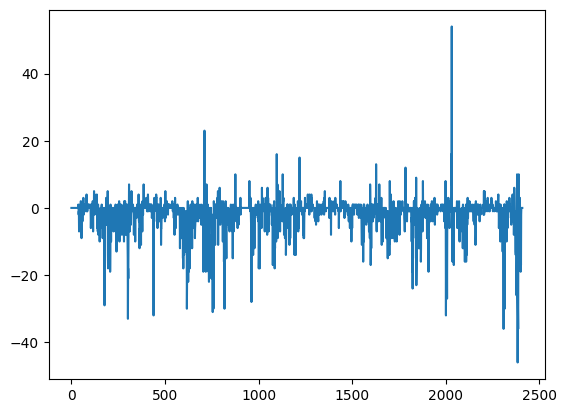

In [34]:
plt.plot(hp1_sums-hp2_sums)

In [19]:
# Choose regions:
# 2032 --> 130_048_000 hp1>hp2
# 2384 --> 152_576_000 hp2>hp1
# 2309 --> 147_776_000 hp2>hp1
# 302 --> 19_328_000 hp2>hp1
# 711 --> 45_504_000 hp1>hp2

In [62]:
locs = [130_048_000, 147_776_000,]# 152_576_000, 19_328_000, 45_504_000]
regions_size = 64000

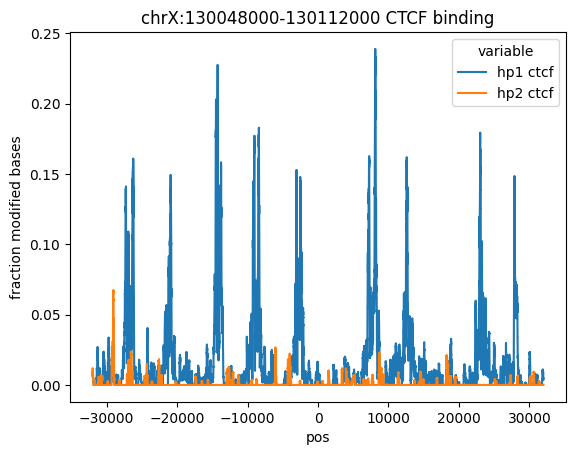

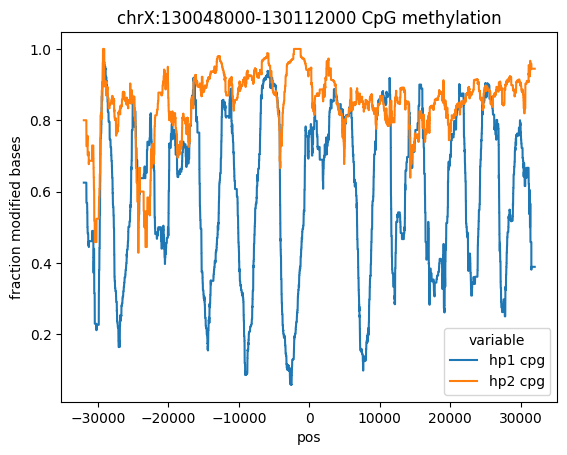

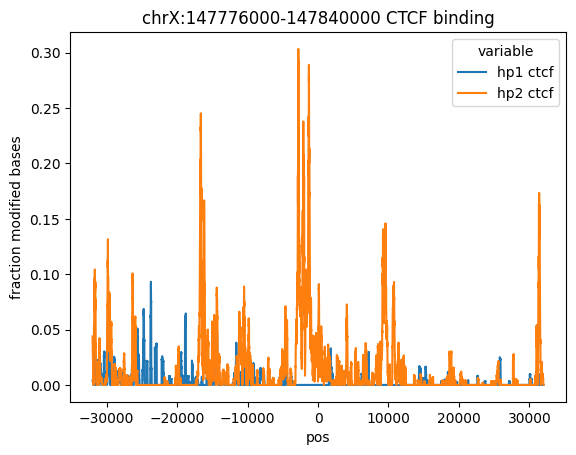

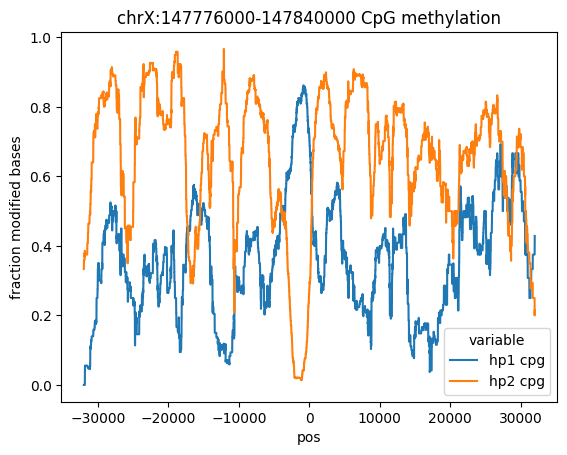

In [65]:
for loc in locs:
    region = f'chrX:{loc}-{loc+regions_size}'
    plot_enrichment_profile.plot_enrichment_profile(
        mod_file_names = [pileup_hp1_allcontext,pileup_hp2_allcontext],
        regions_list = [region,region],
        sample_names = ['hp1 ctcf','hp2 ctcf'],
        motifs = ['A,0','A,0'],
        window_size = None,
        smooth_window = 128,
    )
    plt.title(f'{region} CTCF binding')
    plt.show()
    plot_enrichment_profile.plot_enrichment_profile(
        mod_file_names = [pileup_hp1,pileup_hp2],
        regions_list = [region,region],
        sample_names = ['hp1 cpg','hp2 cpg'],
        motifs = ['CG,0','CG,0'],
        window_size = None,
        smooth_window = 2000,
    )
    plt.title(f'{region} CpG methylation')
    plt.show()

In [60]:
region_size = 64000
region_dicts_dict = {
    'Maternal CTCF':{'chromosome':'chrX',
     'start':130_048_000,
     'end':130_048_000 + region_size,
    },
    'Paternal CTCF':{'chromosome':'chrX',
     'start':147_776_000,
     'end':147_776_000 + region_size,
    },
}
onehot_dicts_dict = {key:defaultdict(list) for key in region_dicts_dict.keys()}
for key,params in region_dicts_dict.items():
    for chunk_start in range(params['start'],params['end'],128):
        # onehot_dicts_dict[key]['combined'].append(
        #     dna_io.one_hot_dna_from_file(
        #         chromosome=params['chromosome'],
        #         start=chunk_start,
        #         end=chunk_start + 896,
        #         ref_genome=ref_genome,
        #         cpg=True,
        #         cpg_bedmethyl=CpG_pileup,
        #         # ablate_list=pwm_matches,
        #     )
        # )
        onehot_dicts_dict[key]['hp1'].append(
            dna_io.one_hot_dna_from_file(
                chromosome=params['chromosome'],
                start=chunk_start,
                end=chunk_start + 896,
                ref_genome=ref_genome,
                cpg=True,
                cpg_bedmethyl=pileup_hp1,
                # ablate_list=pwm_matches,
            )
        )
        onehot_dicts_dict[key]['hp2'].append(
            dna_io.one_hot_dna_from_file(
            chromosome=params['chromosome'],
            start=chunk_start,
            end=chunk_start + 896,
            ref_genome=ref_genome,
            cpg=True,
            cpg_bedmethyl=pileup_hp2,
            # ablate_list=pwm_matches,
        )
    )

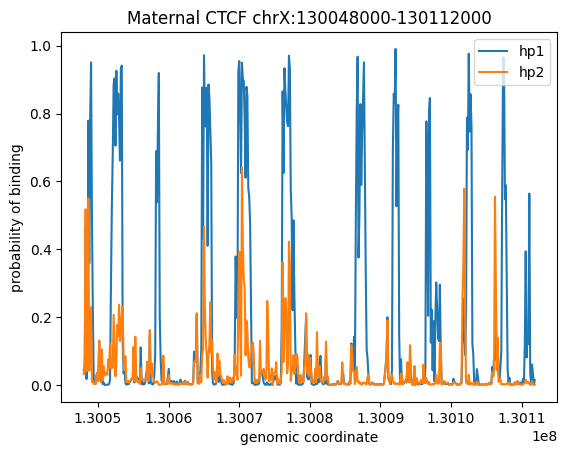

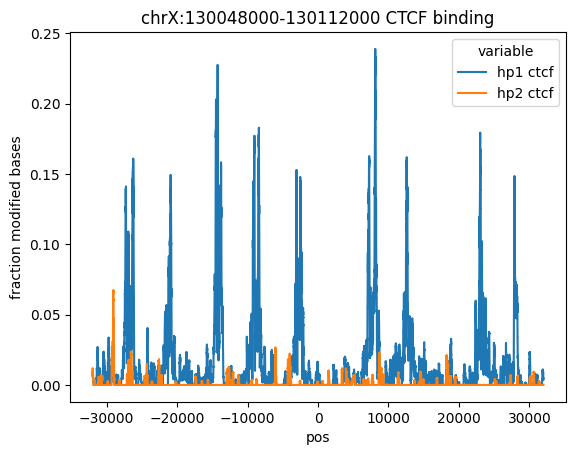

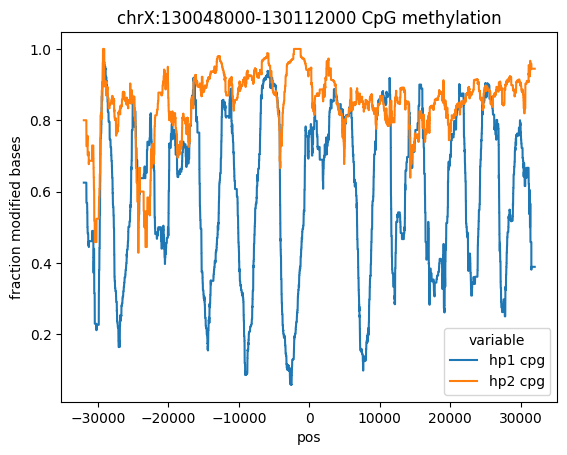

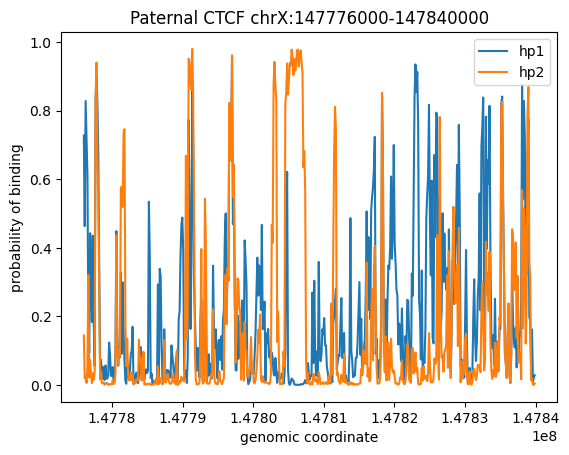

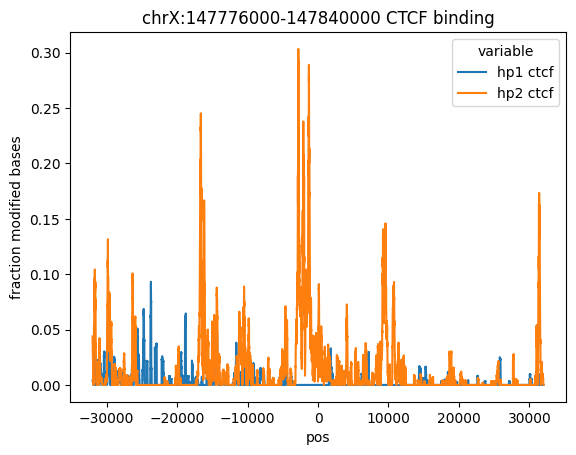

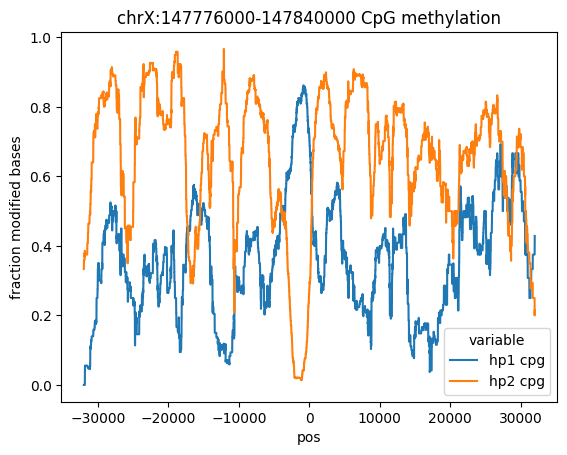

In [67]:
for name,onehot_dict in onehot_dicts_dict.items():
    start = region_dicts_dict[name]['start']
    end = region_dicts_dict[name]['end']
    for haplo,onehot_list in onehot_dict.items():
        predictions = torch.sigmoid(model(torch.tensor(np.transpose(np.array(onehot_list), (0,2,1)),dtype=torch.float32)).detach())
        x_values = range(start,end,(end-start)//len(predictions))
        plt.plot(x_values,predictions,label=haplo)
    plt.title(f'{name} chrX:{start}-{end}')
    plt.ylabel('probability of binding')
    plt.xlabel('genomic coordinate')
    plt.legend()
    plt.show()
    region = f'chrX:{start}-{end}'
    plot_enrichment_profile.plot_enrichment_profile(
        mod_file_names = [pileup_hp1_allcontext,pileup_hp2_allcontext],
        regions_list = [region,region],
        sample_names = ['hp1 ctcf','hp2 ctcf'],
        motifs = ['A,0','A,0'],
        window_size = None,
        smooth_window = 128,
    )
    plt.title(f'{region} CTCF binding')
    plt.show()
    plot_enrichment_profile.plot_enrichment_profile(
        mod_file_names = [pileup_hp1,pileup_hp2],
        regions_list = [region,region],
        sample_names = ['hp1 cpg','hp2 cpg'],
        motifs = ['CG,0','CG,0'],
        window_size = None,
        smooth_window = 2000,
    )
    plt.title(f'{region} CpG methylation')
    plt.show()